# CPSC 483 — Classwork: Random Forest on Auto-MPG

**Task (slide 25):** Load `autompg.csv`, use a `RandomForestClassifier` with **100 trees** to classify **Cylinders** from the other features, **drop the last column (model name)**, and **visualize a tree**.

*Idioms follow Géron's `handson-mlp` ch.6 reference: `rnd_clf` naming, `n_jobs=-1`, `random_state=42`. A random forest has 100 trees, so "visualize the decision tree" means plotting one representative member, `rnd_clf.estimators_[0]`.*

## Setup

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

## Load the data
In Colab, upload `autompg.csv` to the session (or adjust the path).

In [2]:
df = pd.read_csv("autompg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


## Prepare features and target
- **Drop the last column** (`car_name`) — a text identifier with no generalizable signal, and a classifier can't use a raw string.
- **Drop rows with missing values** — six cars have an unknown `horsepower`.
- **Target** = `cylinders` (discrete counts {3,4,5,6,8} → a classification problem); **features** = everything else.

No scaling or train/test split: trees don't need scaling, and slide 25 asks for neither (unlike the AdaBoost classwork on slide 40).

In [3]:
df = df.iloc[:, :-1].dropna()        # drop last column (car_name); drop the 6 missing-horsepower rows
y = df["cylinders"]
X = df.drop(columns=["cylinders"])
print("Features:", list(X.columns), "| samples:", len(X), "| classes:", sorted(y.unique()))

Features: ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin'] | samples: 392 | classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8)]


## Train the Random Forest (100 trees)
`n_estimators=100` grows 100 trees, each on a bootstrap sample of rows and choosing splits from a random feature subset — the two sources of randomness that decorrelate the trees and lower variance.

In [4]:
rnd_clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rnd_clf.fit(X, y)
print("Trees in the forest:", len(rnd_clf.estimators_))

Trees in the forest: 100


## Visualize one tree from the forest
We plot `rnd_clf.estimators_[0]`. The trees grow deep (~9 levels), so `max_depth=3` caps the **displayed** depth only — it does not change the trained model. Remove it to draw the full tree.

Each node shows the split rule, **gini** impurity, **samples** reaching it (the root's count is the ~63% distinct rows from this tree's bootstrap), per-class **value** counts, and predicted **class**.

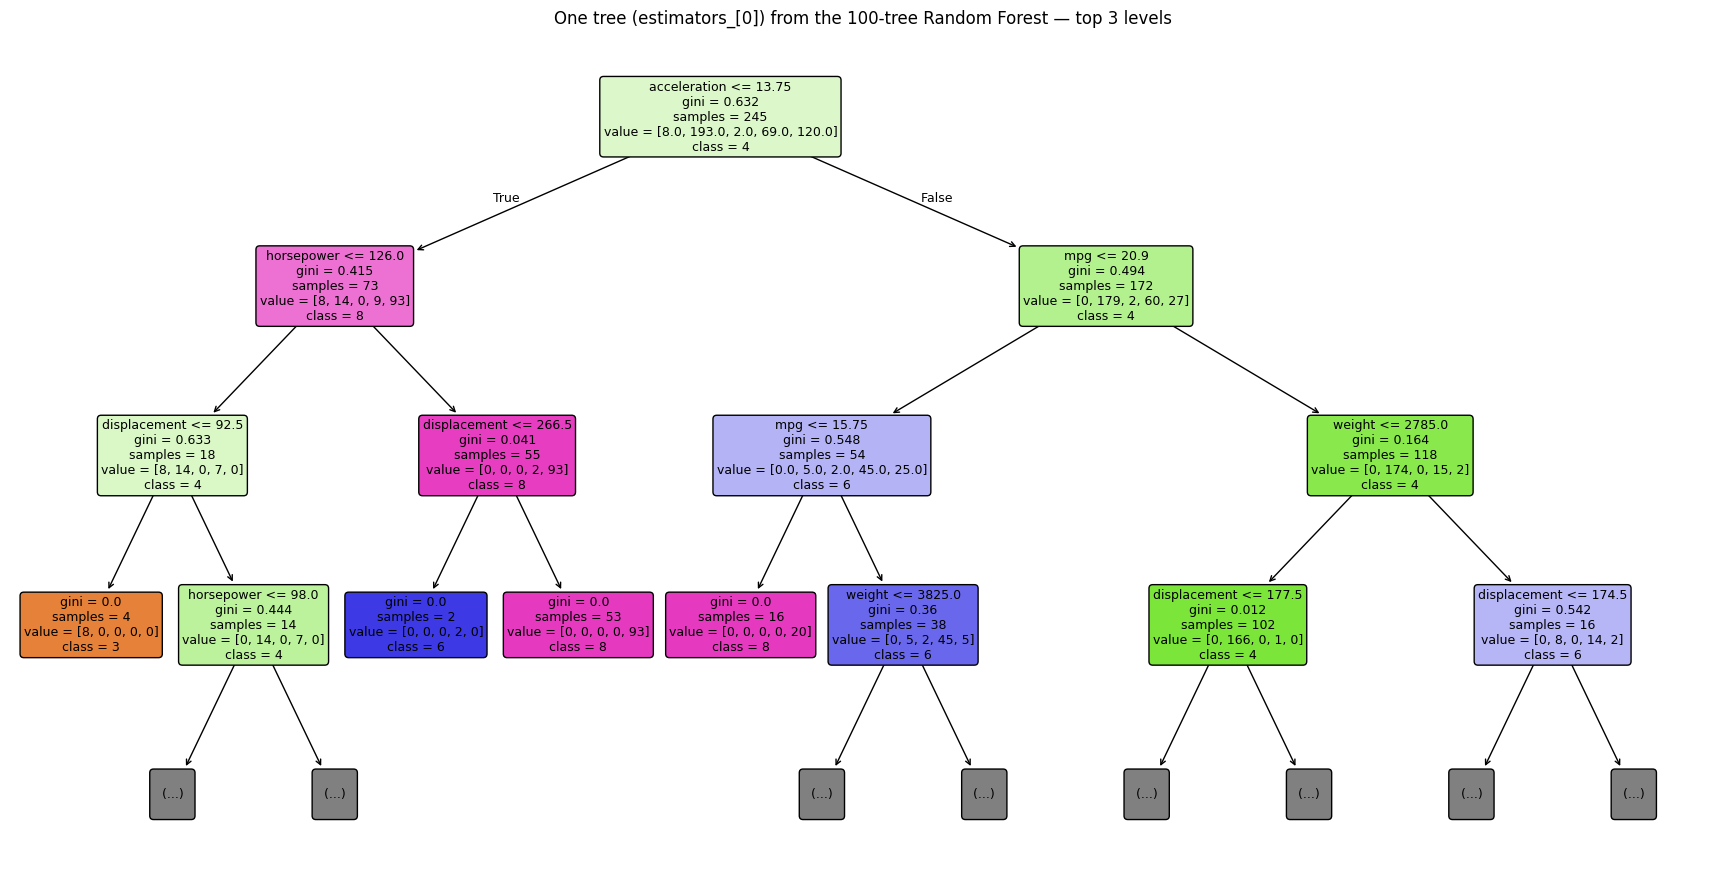

In [5]:
plt.figure(figsize=(22, 11))
plot_tree(
    rnd_clf.estimators_[0],
    feature_names=list(X.columns),
    class_names=[str(cls) for cls in rnd_clf.classes_],
    filled=True, rounded=True, fontsize=9,
    max_depth=3,                     # display cap only; remove for the full tree
)
plt.title("One tree (estimators_[0]) from the 100-tree Random Forest — top 3 levels")
plt.show()